In [16]:
from sklearn import datasets
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt

Load data

In [17]:
cancer = datasets.load_breast_cancer()

Concert to pandas data frame.

In [18]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


Task 1. - Compute the base rate of malignant cancer occurrence over the entire data set. In other words, what
would be your best guess for the probability of malignant cancer of a single example using 
only the labels in the training set? This question is very simple, so try not to overthink it.

In [19]:
total_count = df.count()
positive_count = df['target'].sum()
negative_count = total_count['target'] - positive_count
print(f"Probabilty of malignant cancer: {negative_count / total_count['target']}")

Probabilty of malignant cancer: 0.37258347978910367


Task 2. - The goal is to build a decision tree that, based on the other features in the set, predicts whether or not a patient...

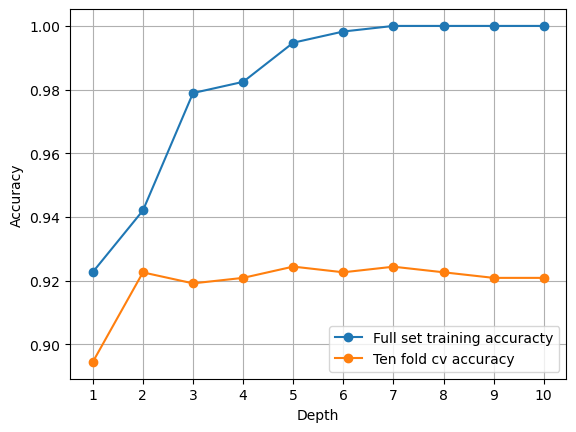

In [27]:
x = cancer.data
y = cancer.target

detph = range(1, 11)
train_accuracy = []
cv_accuracy  = []

kf = KFold(n_splits=10, shuffle=True, random_state=10)

for d in detph:
    tree = DecisionTreeClassifier(max_depth=d, random_state=10)
        
    # All the set accruacy
    tree.fit(x, y)
    train_accu=tree.score(x, y)
    train_accuracy.append(train_accu)

    # Ten folds cv accu    
    scores = cross_val_score(tree, x, y, cv=kf)
    cv_accuracy.append(scores.mean())

plt.figure()
plt.plot(detph, train_accuracy, marker='o', label='Full set training accuracty')
plt.plot(detph, cv_accuracy, marker='o', label='Ten fold cv accuracy')
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.xticks(detph)
plt.grid(True)
plt.legend()
plt.show()

Answers:

i. What setting of max depth gave the best accuracy w.r.t. the full-dataset accuracy?
If more than one setting equaled the best accuracy, list each of the best settings.

In my opinion, the highest and the best accuracy for full data set is for max_depths 7, 8, 9, and 10.

ii. What setting of max depth gave the best accuracy w.r.t. the cross-validated
accuracy? If more than one setting equaled the best accuracy, list each of the best
settings.

From my point of view, from the graph the best 10 fold cv is achieved at depth 5 and 7.

Task 3. This question explores random forest classifiers...

/tmp/ipykernel_24339/528092798.py:17: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  plt.plot(n_estimators, cv_accuracy, marker='o', Label='Ten fold cv accuracy')


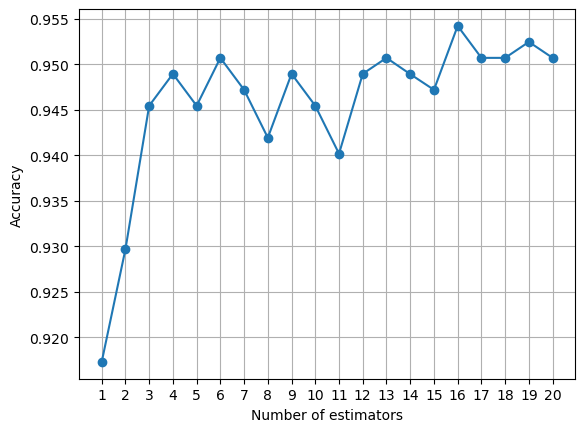

In [26]:
x = cancer.data
y = cancer.target

n_estimators = range(1, 21)
cv_accuracy  = []
d = 5 # I set this from 2.b from cv result

kf = KFold(n_splits=10, shuffle=True, random_state=10)

for e in n_estimators:
    ensemble = RandomForestClassifier(max_depth=d, n_estimators=e, random_state=10)
    
    scores = cross_val_score(ensemble, x, y, cv=kf)
    cv_accuracy.append(scores.mean())    
    
plt.figure()
plt.plot(n_estimators, cv_accuracy, marker='o', Label='Ten fold cv accuracy')
plt.xlabel('Number of estimators')
plt.xticks(n_estimators)
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

b) Do you see an improvement using random forests...

Yes, using RandomForestClassifier improves accuracy in comparision to a single Decision Tree. The cv increases from roughly 92% to 95% for max dept = 5 for 16 trees.

c) hat setting of n estimators gave the best accuracy w.r.t. the ...

The highest score for cv accuracy is achieved with 16 estimators/trees.

d) For the second plot, again use a ensemble.RandomForestClassifier...

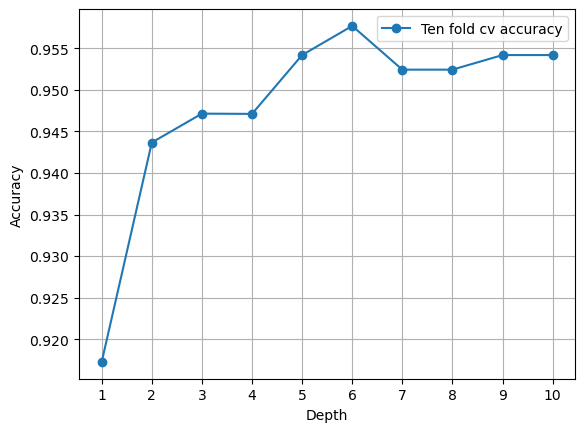

In [28]:
x = cancer.data
y = cancer.target

n_estimator = 16
cv_accuracy  = []
depth = range(1, 11)

kf = KFold(n_splits=10, shuffle=True, random_state=10)

for d in depth:
    ensemble = RandomForestClassifier(max_depth=d, n_estimators=n_estimator, random_state=10)
    
    scores = cross_val_score(ensemble, x, y, cv=kf)
    cv_accuracy.append(scores.mean())    
    

plt.figure()
plt.plot(detph, cv_accuracy, marker='o', label='Ten fold cv accuracy')
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.xticks(detph)
plt.grid(True)
plt.legend()
plt.show()

e) In the plot in 3d, is the optimal setting of max depth the same as in 2(b)ii?
If not, what is the new optimal setting of max depth?

No, the optimal max_depth from the Random Forests is not the same as for the single decision tree! 
Max depth from my graph is now 6. In contrast, previous (2b ii) was 5. However, it is quet close to the one from the previous exercise. 

Task 4. For this last question, we will explore the dependability of our estimates

a)  Make a plot using the following procedure:

i. Using random state values from 0, 1, · · · , 99 calculate...

ii. Plot the counts for the best max depth settings as a bar chart with...

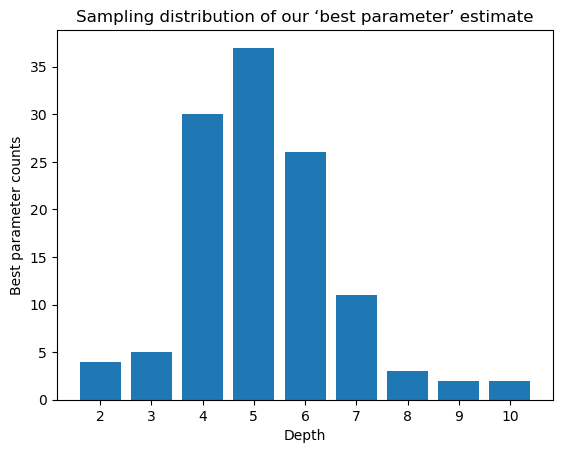

In [23]:
x = cancer.data
y = cancer.target

depth = range(1, 11)
random_states = range(0, 100)

best_depths = {}

for r_state in random_states:
    depth_scores = {}

    for d in depth:
        tree = DecisionTreeClassifier(max_depth=d, random_state=r_state)
        kf = KFold(n_splits=10, shuffle=True, random_state=r_state)
        
        scores = cross_val_score(tree, x, y, cv=kf)
        depth_scores[d] = scores.mean()
    
    best_score = max(depth_scores.values())

    for d, score in depth_scores.items():
        if score == best_score:
            if d not in best_depths:
                best_depths[d] = 1
            else:
                best_depths[d] += 1
                

x = sorted(best_depths.keys())
y = [best_depths[key] for key in x]

plt.xlabel('Depth')
plt.ylabel('Best parameter counts')
plt.title("Sampling distribution of our ‘best parameter’ estimate")
plt.xticks(x)
plt.bar(x, y)
plt.show()

b) What are the top two most frequent parameter settings?

The top two most frequent parameter settings are: 5 and 4.